<a href="https://colab.research.google.com/github/krishnatiwari4919/MLE-case-study-2/blob/main/MLE_Caste_Study_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

df_trans = pd.read_csv('train_transaction.csv')
df_id = pd.read_csv('train_identity.csv')

df = pd.merge(df_trans, df_id, on='TransactionID', how='left')
df = df.drop(columns = 'TransactionID', axis = 1)

In [ ]:
df = df.fillna(-999)

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('isFraud', axis = 1)
y = df['isFraud']
X = pd.get_dummies(X, drop_first = True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state = 42)

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
from xgboost import XGBClassifier, plot_importance
xgb_model = XGBClassifier(n_estimators = 100, learning_rate = 0.1, max_depth = 5,
                          eval_metric = 'logloss', random_state = 42)
xgb_model.fit(X_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import roc_auc_score, classification_report
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
custom_threshold = 0.15
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)
print(roc_auc_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred_custom))

0.8825208877055929
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1543
           1       0.40      0.51      0.45        37

    accuracy                           0.97      1580
   macro avg       0.70      0.75      0.72      1580
weighted avg       0.97      0.97      0.97      1580



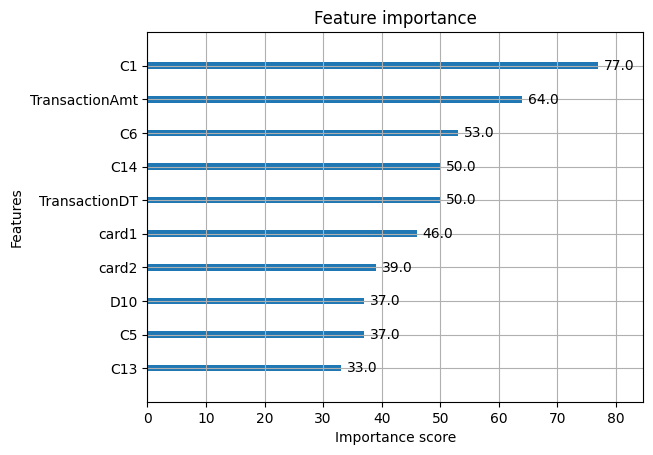

In [ ]:
import matplotlib.pyplot as plt
plot_importance(xgb_model, max_num_features = 10, importance_type = 'weight')
plt.show()

In [ ]:
print("Loading test data...")
test_trans = pd.read_csv('test_transaction.csv')
test_id = pd.read_csv('test_identity.csv')
test_df = pd.merge(test_trans, test_id, on='TransactionID', how='left')

submission_ids = test_df['TransactionID']
test_df = test_df.drop('TransactionID', axis=1, errors='ignore')


test_df = pd.get_dummies(test_df, drop_first=True)


train_cols = X.columns


missing_cols = set(train_cols) - set(test_df.columns)
for c in missing_cols:
    test_df[c] = -999

extra_cols = set(test_df.columns) - set(train_cols)
test_df = test_df.drop(columns=list(extra_cols), errors='ignore')


test_df = test_df[train_cols]


test_df = test_df.fillna(-999)

test_predictions = xgb_model.predict_proba(test_df)[:, 1]

submission = pd.DataFrame({
    'TransactionID': submission_ids,
    'isFraud': test_predictions
})
submission.to_csv('my_assessment_answers.csv', index=False)
print("Success! 'my_assessment_answers.csv' is ready to upload.")

Loading test data...


/tmp/ipykernel_1939/1804336615.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df[c] = -999
/tmp/ipykernel_1939/1804336615.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df[c] = -999
/tmp/ipykernel_1939/1804336615.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df[c] = 

Success! 'my_assessment_answers.csv' is ready to upload.
